# cleaning bafta csv 

In [3]:
import pandas as pd
#load the bafta.csv file
bafta_df=pd.read_csv('bafta.csv')
# removing irrelevant columns from the data set - "worker" column
bafta_df=bafta_df.drop(columns=['workers'])
#saving the changes back to the same csv as i wont use that column at all
bafta_df.to_csv('bafta.csv', index=False)
#checking what it 
print(bafta_df.head())


   year                     category               nominee  winner
0  1949  Film | British Film in 1949       The Fallen Idol    True
1  1949  Film | British Film in 1949                Hamlet   False
2  1949  Film | British Film in 1949          Oliver Twist   False
3  1949  Film | British Film in 1949  Once A Jolly Swagman   False
4  1949  Film | British Film in 1949         The Red Shoes   False


# cleaning golden globes csv

In [19]:
#loading the golden globes csv file
golden_globes=pd.read_csv('golden_globe.csv')
#dropping irrelevant columns: 'year_film' and 'ceremony'
golden_globes=golden_globes.drop(columns=['year_film', 'ceremony'])
# again savign it back to the same csv
golden_globes.to_csv('golden_globe.csv', index=False)


In [38]:
#reloading csv
golden_globes=pd.read_csv('golden_globe.csv')
#renaming the columns so that tthey match the ones in bafta so its easier to merge later 
golden_globes=golden_globes.rename(columns={
    'year_award': 'year',
    'movie_title': 'nominee'
})
golden_globes.to_csv('golden_globe.csv', index=False)


In [40]:
globes_df=pd.read_csv('golden_globe.csv')
#I forgot to rename the column winner drk why ive put it in a seperate cell
globes_df=globes_df.rename(columns={'win': 'winner'})
globes_df.to_csv('golden_globe.csv', index=False)


# cleaning oscars csv 

In [21]:
#loading the oscars csv
oscars=pd.read_csv('oscars.csv')
#dropping irrelevant columns 
oscars=oscars.drop(columns=['year_film', 'ceremony', 'canon_category', 'name'])
#saving it back to the same file
oscars.to_csv('oscars.csv', index=False)

In [25]:
#renaming the columns so it matches the previous two and saving it back to the same csv
oscars=pd.read_csv('oscars.csv')
oscars=oscars.rename(columns={
    'year_ceremony': 'year',
    'film': 'nominee'
})
oscars.to_csv('oscars.csv', index=False)


# adding "awarding body" column and creating combined_awards.csv

In [68]:
#loading the cleaned csv files
oscars_df=pd.read_csv('oscars.csv')
baftas_df=pd.read_csv('bafta.csv')
globes_df=pd.read_csv('golden_globe.csv')
#adding a column called awarding body so i can differentiate between awards (not sure if ill undo this later cos idk if its gonna be useful)
oscars_df['award_body']='Oscars'
baftas_df['award_body']='BAFTAs'
globes_df['award_body']='Golden Globes'
#combining them into one data frame and saving it to a new csv file 
combined_awards_df= pd.concat([oscars_df, baftas_df, globes_df], ignore_index=True)
combined_awards_df.to_csv('combined_awards.csv', index=False)
combined_awards_df.head(200)


,year,category,nominee,winner,award_body
0,1928,ACTOR,The Noose,False,Oscars
1,1928,ACTOR,The Patent Leather Kid,False,Oscars
2,1928,ACTOR,The Last Command,True,Oscars
3,1928,ACTOR,The Way of All Flesh,True,Oscars
4,1928,ACTRESS,A Ship Comes In,False,Oscars
...,...,...,...,...,...
195,1932,OUTSTANDING PRODUCTION,Five Star Final,False,Oscars
196,1932,OUTSTANDING PRODUCTION,Grand Hotel,True,Oscars
197,1932,OUTSTANDING PRODUCTION,One Hour with You,False,Oscars
198,1932,OUTSTANDING PRODUCTION,Shanghai Express,False,Oscars


# checking what award categories there are 

In [56]:
for category in combined_awards_df['category'].unique():
    print(category)
#checking what award titles there are so i can find a way to categorise them 


ACTOR
ACTRESS
ART DIRECTION
CINEMATOGRAPHY
DIRECTING (Comedy Picture)
DIRECTING (Dramatic Picture)
ENGINEERING EFFECTS
OUTSTANDING PICTURE
UNIQUE AND ARTISTIC PICTURE
WRITING (Adaptation)
WRITING (Original Story)
WRITING (Title Writing)
SPECIAL AWARD
DIRECTING
WRITING
OUTSTANDING PRODUCTION
SOUND RECORDING
SHORT SUBJECT (Cartoon)
SHORT SUBJECT (Comedy)
SHORT SUBJECT (Novelty)
ASSISTANT DIRECTOR
FILM EDITING
MUSIC (Scoring)
MUSIC (Song)
DANCE DIRECTION
WRITING (Screenplay)
ACTOR IN A SUPPORTING ROLE
ACTRESS IN A SUPPORTING ROLE
SHORT SUBJECT (Color)
SHORT SUBJECT (One-reel)
SHORT SUBJECT (Two-reel)
IRVING G. THALBERG MEMORIAL AWARD
MUSIC (Original Score)
CINEMATOGRAPHY (Black-and-White)
CINEMATOGRAPHY (Color)
SPECIAL EFFECTS
ART DIRECTION (Black-and-White)
ART DIRECTION (Color)
WRITING (Original Screenplay)
DOCUMENTARY (Short Subject)
MUSIC (Music Score of a Dramatic Picture)
MUSIC (Scoring of a Musical Picture)
OUTSTANDING MOTION PICTURE
DOCUMENTARY
MUSIC (Music Score of a Dramatic or 

# creating film_awards_summary.csv

In [46]:
#loading the combined csv
df=pd.read_csv('combined_awards.csv')
#renaming nominee to 'film'(this matches the other data set im going to combine later)
df=df.rename(columns={'nominee': 'title'})
#creating a new awards column that combines award_body, category, and win/nomination info
def award_text(row):
    if row['winner']==True or row['winner']=='TRUE':
        result=f"{row['award_body']} - {row['category']}(Won)"
    else:
        result=f"{row['award_body']} - {row['category']}(Nominated)"
    return result
df['award_info']=df.apply(award_text, axis=1)
#grouping by film and separating nominations and wins into two columns
grouped = df.groupby('title').agg({
    'award_info': lambda x: "\n".join(x),
    'winner': ['count', lambda x: (x==True).sum() + (x == 'TRUE').sum()]
})
grouped['awards_won']=df[df['winner']==True].groupby('title')['award_info'].apply(lambda x: "\n".join(x))
grouped['awards_nominated']=df[df['winner'] != True].groupby('title')['award_info'].apply(lambda x: "\n".join(x))
#changing the column names 
grouped.columns=['awards_all', 'nomination_count', 'award_count', 'awards_won', 'awards_nominated']
grouped = grouped.reset_index()
grouped.to_csv('film_awards_summary.csv', index=False)
#checking it all works 
(grouped.head(30))

,title,awards_all,nomination_count,award_count,awards_won,awards_nominated
0,"Remains of the Day, The",Golden Globes - Best Motion Picture - Drama(No...,5,0,NaN,Golden Globes - Best Motion Picture - Drama(No...
1,Roma (1972),Golden Globes - Foreign Film - Foreign Languag...,1,0,NaN,Golden Globes - Foreign Film - Foreign Languag...
2,"$1,000 a Minute",Oscars - SOUND RECORDING(Nominated),1,0,NaN,Oscars - SOUND RECORDING(Nominated)
3,"$1,000,000 Duck",Golden Globes - Best Performance by an Actor i...,2,0,NaN,Golden Globes - Best Performance by an Actor i...
4,'38',Oscars - FOREIGN LANGUAGE FILM(Nominated),1,0,NaN,Oscars - FOREIGN LANGUAGE FILM(Nominated)
5,'Crocodile' Dundee,Oscars - WRITING (Screenplay Written Directly ...,1,0,NaN,Oscars - WRITING (Screenplay Written Directly ...
6,'Round Midnight,Oscars - ACTOR IN A LEADING ROLE(Nominated)\nO...,4,1,Oscars - MUSIC (Original Score)(Won),Oscars - ACTOR IN A LEADING ROLE(Nominated)\nG...
7,"'night, Mother",Golden Globes - Best Performance by an Actress...,1,0,NaN,Golden Globes - Best Performance by an Actress...
8,(500) Days of Summer,Golden Globes - Best Motion Picture - Musical ...,2,0,NaN,Golden Globes - Best Motion Picture - Musical ...
9,(A) Torzija [(A) Torsion],Oscars - SHORT FILM (Live Action)(Nominated),1,0,NaN,Oscars - SHORT FILM (Live Action)(Nominated)


# loading rotten tomatoes and removing % sign 

In [48]:
#loading the rotten tomatoes csv 
movie_info=pd.read_csv('movie_info.csv')
#dropping irrelevant columnns: url and release_date
movie_info=movie_info.drop(columns=['url', 'release_date'])
#remvoing % so that the columns will be used as numeric 
movie_info['critic_score'] = movie_info['critic_score'].str.replace('%', '', regex=False).astype(float)
movie_info['audience_score'] = movie_info['audience_score'].str.replace('%', '', regex=False).astype(float)
movie_info.to_csv('rotten_tomatoes.csv', index=False)
(movie_info.head(30))


,title,critic_score,audience_score
0,Love Story,63.0,75.0
1,Airport,75.0,54.0
2,M*A*S*H,84.0,83.0
3,Patton,91.0,93.0
4,The Aristocats,NaN,NaN
5,The Aristocats,64.0,70.0
6,Woodstock,100.0,92.0
7,Little Big Man,91.0,87.0
8,Ryan's Daughter,47.0,73.0
9,Tora! Tora! Tora!,55.0,81.0


# creating final_combined_dataset.csv 

In [57]:
#loading award and rotten tomatoes csv 
rt=pd.read_csv('rotten_tomatoes.csv')
awards=pd.read_csv('film_awards_summary.csv')
#Remove rows with missing critic score or audience score
rt=rt.dropna(subset=['critic_score','audience_score'])
#joining the tables on the column title 
combined=pd.merge(rt,awards,on='title', how='left')

combined['awards_nominated']=combined['awards_nominated'].fillna('')
combined['awards_won']=combined['awards_won'].fillna('')
combined['nomination_count']=combined['nomination_count'].fillna(0).astype(int)
combined['award_count']=combined['award_count'].fillna(0).astype(int)

combined.to_csv('final_combined_dataset.csv', index=False)
(combined.head(10))

,title,critic_score,audience_score,awards_all,nomination_count,award_count,awards_won,awards_nominated
0,Love Story,63.0,75.0,Oscars - ACTOR(Nominated)\nOscars - ACTOR IN A...,14,6,Oscars - MUSIC (Original Score)(Won)\nGolden G...,Oscars - ACTOR(Nominated)\nOscars - ACTOR IN A...
1,Airport,75.0,54.0,Oscars - ACTRESS IN A SUPPORTING ROLE(Won)\nOs...,14,2,Oscars - ACTRESS IN A SUPPORTING ROLE(Won)\nGo...,Oscars - ACTRESS IN A SUPPORTING ROLE(Nominate...
2,M*A*S*H,84.0,83.0,Oscars - ACTRESS IN A SUPPORTING ROLE(Nominate...,16,3,Oscars - WRITING (Screenplay--based on materia...,Oscars - ACTRESS IN A SUPPORTING ROLE(Nominate...
3,Patton,91.0,93.0,Oscars - ACTOR(Won)\nOscars - ART DIRECTION(Wo...,13,8,Oscars - ACTOR(Won)\nOscars - ART DIRECTION(Wo...,Oscars - CINEMATOGRAPHY(Nominated)\nOscars - M...
4,The Aristocats,64.0,70.0,NaN,0,0,,
5,Woodstock,100.0,92.0,Oscars - DOCUMENTARY (Feature)(Won)\nOscars - ...,3,1,Oscars - DOCUMENTARY (Feature)(Won),Oscars - FILM EDITING(Nominated)\nOscars - SOU...
6,Little Big Man,91.0,87.0,Oscars - ACTOR IN A SUPPORTING ROLE(Nominated)...,4,0,,Oscars - ACTOR IN A SUPPORTING ROLE(Nominated)...
7,Ryan's Daughter,47.0,73.0,Oscars - ACTOR IN A SUPPORTING ROLE(Won)\nOsca...,14,3,Oscars - ACTOR IN A SUPPORTING ROLE(Won)\nOsca...,Oscars - ACTRESS(Nominated)\nOscars - SOUND(No...
8,Tora! Tora! Tora!,55.0,81.0,Oscars - ART DIRECTION(Nominated)\nOscars - CI...,5,1,Oscars - SPECIAL VISUAL EFFECTS(Won),Oscars - ART DIRECTION(Nominated)\nOscars - CI...
9,Catch-22,81.0,76.0,Golden Globes - Best Television Limited Series...,2,0,,Golden Globes - Best Television Limited Series...


# creating audience score vs critic score scatter plot colour coding by award

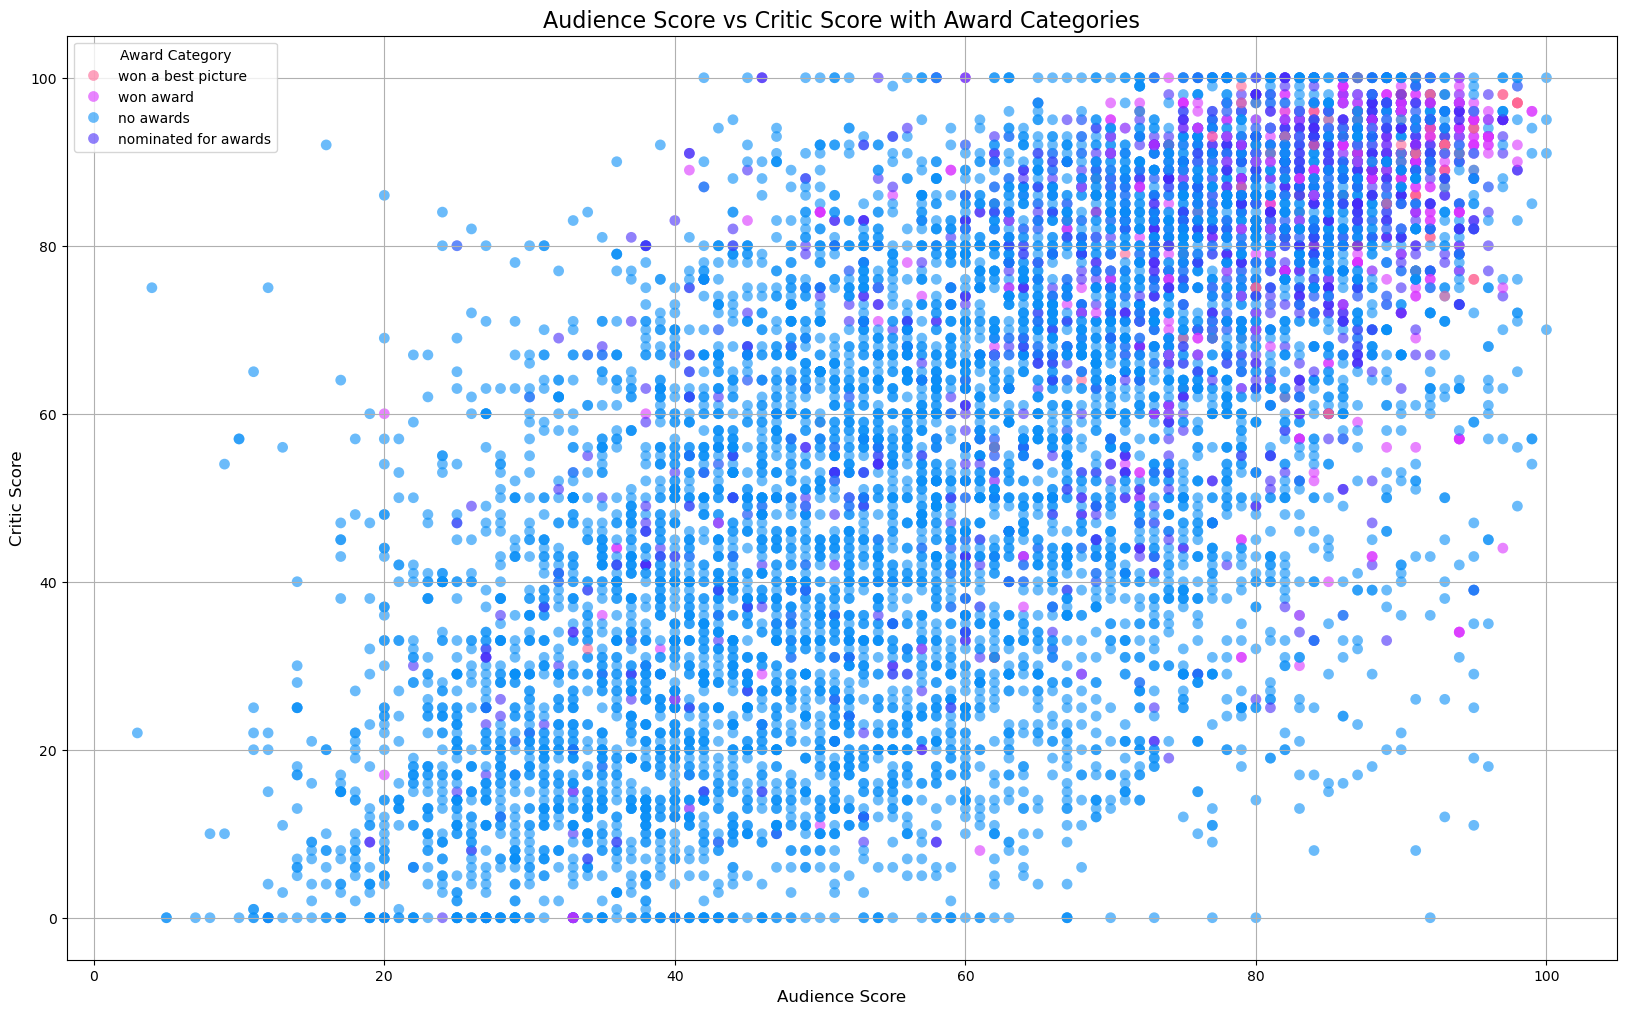

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
#loading the combined dataset
df=pd.read_csv('final_combined_dataset.csv')
# categorising films into: won best picture, won awards, nominated for awards and no awards 
def classify_awards(row):
    #checking if the film has won a best picture type award
    best_picture_keywords=['best picture', 'best motion picture', 'outstanding motion picture', 'best film']
    has_best_picture=any(keyword.lower() in str(row['awards_won']).lower() for keyword in best_picture_keywords)
    #checking if the film has had any awards or nominations 
    has_nominations=pd.notna(row['awards_nominated']) and len(row['awards_nominated']) > 0
    has_wins=pd.notna(row['awards_won']) and len(row['awards_won']) > 0
    if not has_nominations and not has_wins:
        return 'no awards'
    elif has_nominations and not has_wins:
        return 'nominated for awards'
    elif has_wins:
        if has_best_picture:
            return 'won a best picture'
        else:
            return 'won award'
df['award_category']=df.apply(classify_awards, axis=1)
#making sure that rows with missing values in ratings are dropped
df_cleaned=df.dropna(subset=['audience_score', 'critic_score'])


#creatung the scatter plot 
plt.figure(figsize=(20, 12))
# choosing the colour
category_colors= { 'no awards': '#098FF7','nominated for awards': '#472BF9','won award': '#DA33FF','won a best picture': '#FE6593'}
# making the dot sizes smaller and make them transparent with no border so that i can see more information on the catter plot
sns.scatterplot(data=df_cleaned, x='audience_score', y='critic_score', hue='award_category', palette=category_colors, s=60, alpha=0.6, edgecolor='none')
# titles and legende
plt.title('Audience Score vs Critic Score with Award Categories', fontsize=16)
plt.xlabel('Audience Score', fontsize=12)
plt.ylabel('Critic Score', fontsize=12)
plt.legend(title='Award Category')
plt.grid(True)
plt.show()

# getting the mean scores for each category to use in blog post 

In [78]:

df=pd.read_csv('final_combined_dataset.csv')
#using same code from the scatter plot 
def classify_awards(row):
    best_picture_keywords=['best picture', 'best motion picture', 'outstanding motion picture', 'best film']
    has_best_picture=any(keyword.lower() in str(row['awards_won']).lower() for keyword in best_picture_keywords)
    has_nominations=pd.notna(row['awards_nominated']) and len(row['awards_nominated']) > 0
    has_wins=pd.notna(row['awards_won']) and len(row['awards_won']) > 0
    if not has_nominations and not has_wins:
        return 'no awards'
    elif has_nominations and not has_wins:
        return 'nominated for awards'
    elif has_wins:
        if has_best_picture:
            return 'won a best picture'
        else:
            return 'won award'
df['award_category'] = df.apply(classify_awards, axis=1)
# calculating averages 
averages=df.groupby('award_category')[['critic_score', 'audience_score']].mean()
print(averages)


                      critic_score  audience_score
award_category                                    
no awards                52.216597       58.081869
nominated for awards     72.115414       71.593014
won a best picture       84.826816       83.815642
won award                80.718894       79.569892


# adding box office to final_combined_dataset.csv creating success_metrics.csv

In [81]:
movies_df=pd.read_csv('worldwide_box_office_movies.csv')
final_combined_df=pd.read_csv('final_combined_dataset.csv')
#merging the datasets on the 'title' column
merged_df=pd.merge(final_combined_df, movies_df[['title', 'worldwide_gross']], on='title', how='left')
#saving it as anew csv called success_metrics 
merged_df.to_csv('success_metrics.csv', index=False)
(merged_df.head(20))


,title,critic_score,audience_score,awards_all,nomination_count,award_count,awards_won,awards_nominated,worldwide_gross
0,Love Story,63.0,75.0,Oscars - ACTOR(Nominated)\nOscars - ACTOR IN A...,14,6,Oscars - MUSIC (Original Score)(Won)\nGolden G...,Oscars - ACTOR(Nominated)\nOscars - ACTOR IN A...,136397186.0
1,Airport,75.0,54.0,Oscars - ACTRESS IN A SUPPORTING ROLE(Won)\nOs...,14,2,Oscars - ACTRESS IN A SUPPORTING ROLE(Won)\nGo...,Oscars - ACTRESS IN A SUPPORTING ROLE(Nominate...,100489150.0
2,M*A*S*H,84.0,83.0,Oscars - ACTRESS IN A SUPPORTING ROLE(Nominate...,16,3,Oscars - WRITING (Screenplay--based on materia...,Oscars - ACTRESS IN A SUPPORTING ROLE(Nominate...,81600193.0
3,Patton,91.0,93.0,Oscars - ACTOR(Won)\nOscars - ART DIRECTION(Wo...,13,8,Oscars - ACTOR(Won)\nOscars - ART DIRECTION(Wo...,Oscars - CINEMATOGRAPHY(Nominated)\nOscars - M...,62500000.0
4,The Aristocats,64.0,70.0,NaN,0,0,NaN,NaN,191000000.0
5,Woodstock,100.0,92.0,Oscars - DOCUMENTARY (Feature)(Won)\nOscars - ...,3,1,Oscars - DOCUMENTARY (Feature)(Won),Oscars - FILM EDITING(Nominated)\nOscars - SOU...,34699266.0
6,Little Big Man,91.0,87.0,Oscars - ACTOR IN A SUPPORTING ROLE(Nominated)...,4,0,NaN,Oscars - ACTOR IN A SUPPORTING ROLE(Nominated)...,31559552.0
7,Ryan's Daughter,47.0,73.0,Oscars - ACTOR IN A SUPPORTING ROLE(Won)\nOsca...,14,3,Oscars - ACTOR IN A SUPPORTING ROLE(Won)\nOsca...,Oscars - ACTRESS(Nominated)\nOscars - SOUND(No...,30846716.0
8,Tora! Tora! Tora!,55.0,81.0,Oscars - ART DIRECTION(Nominated)\nOscars - CI...,5,1,Oscars - SPECIAL VISUAL EFFECTS(Won),Oscars - ART DIRECTION(Nominated)\nOscars - CI...,29548291.0
9,Catch-22,81.0,76.0,Golden Globes - Best Television Limited Series...,2,0,NaN,Golden Globes - Best Television Limited Series...,24911670.0


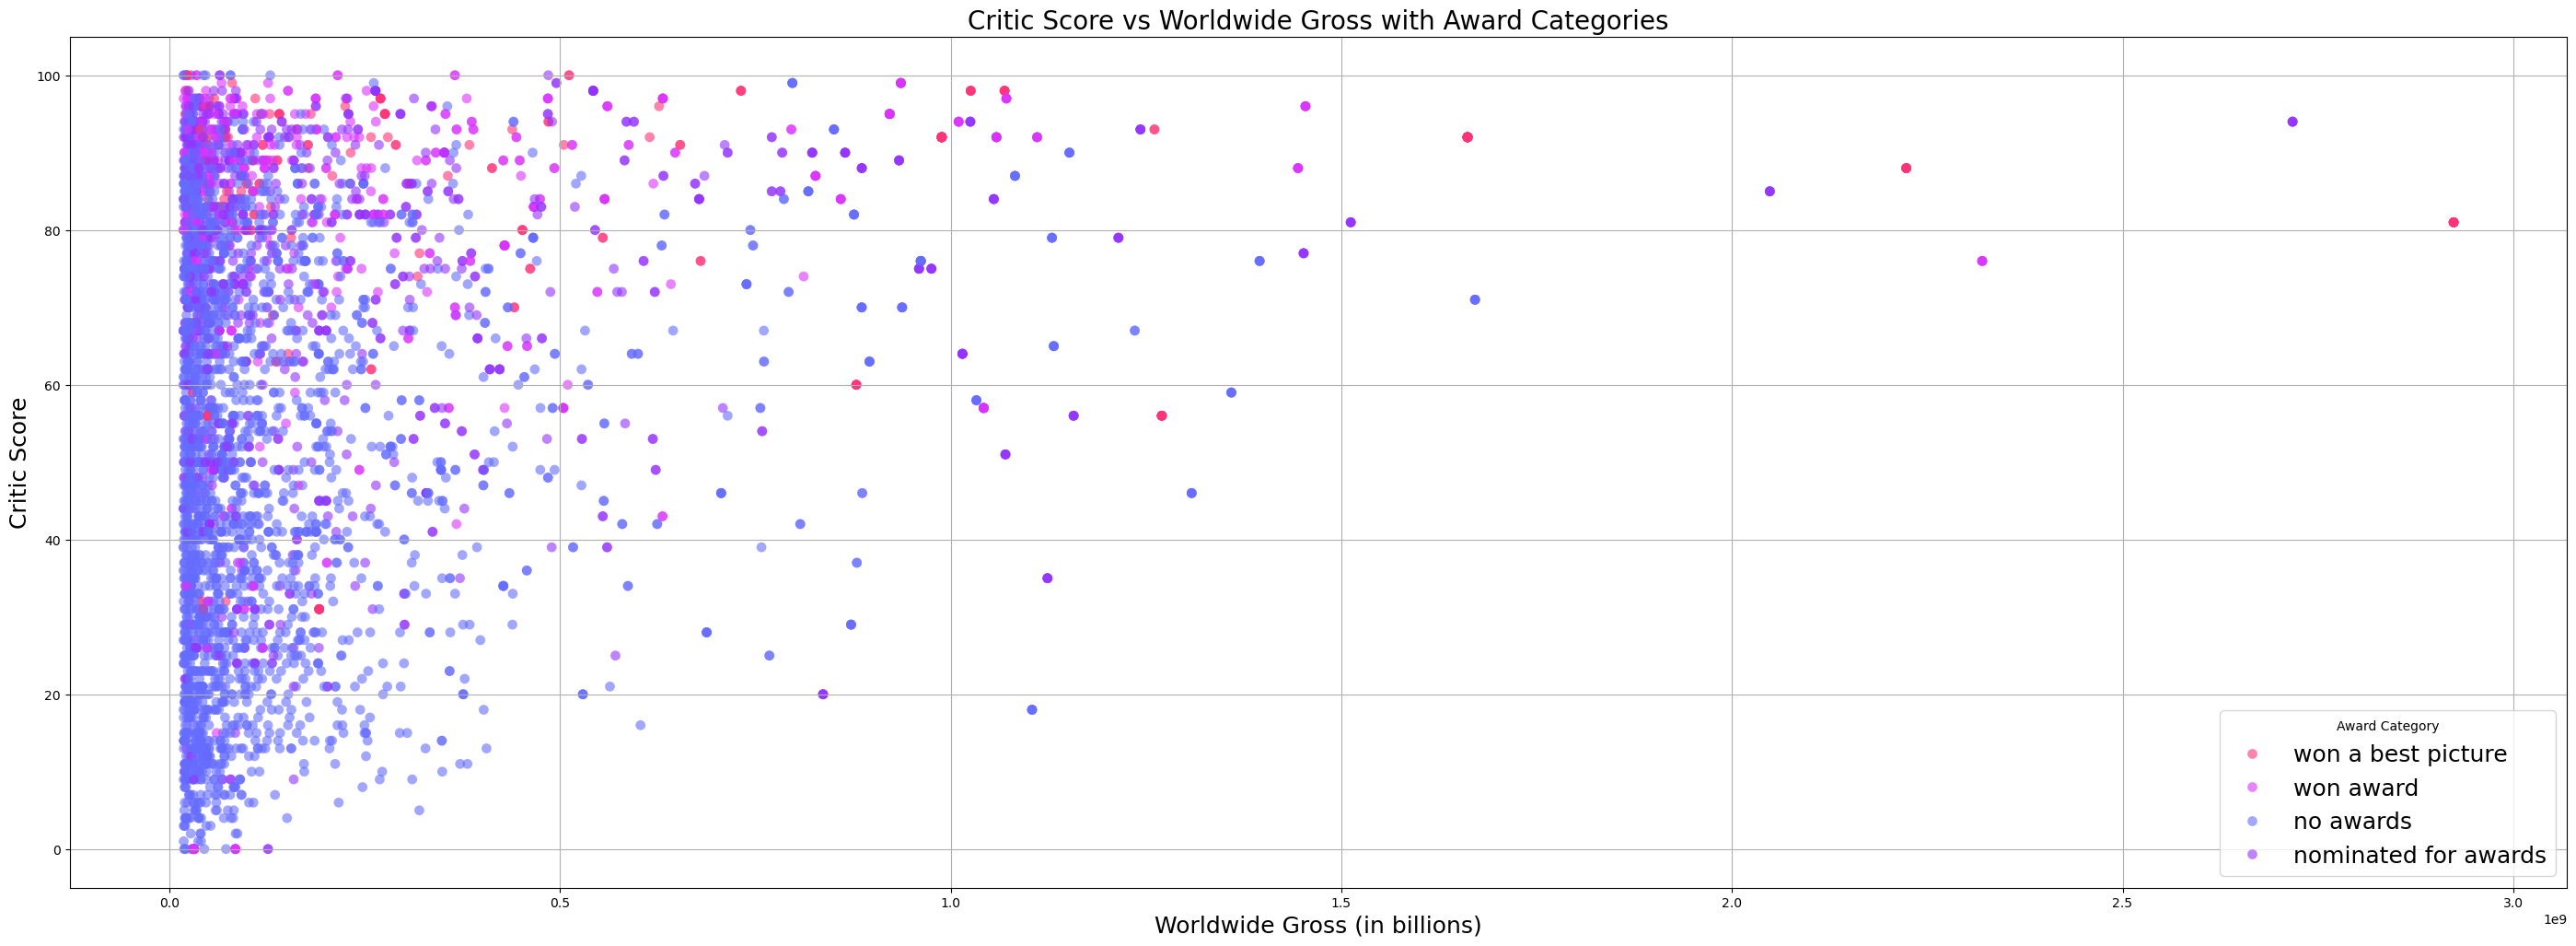

In [109]:
#loading the success_metrics dataset
df=pd.read_csv('success_metrics.csv')
#using the same code to classify awards
def classify_awards(row):
    best_picture_keywords=['best picture', 'best motion picture', 'outstanding motion picture', 'best film']
    has_best_picture=any(keyword.lower() in str(row['awards_won']).lower() for keyword in best_picture_keywords)
    has_nominations=pd.notna(row['awards_nominated']) and len(row['awards_nominated']) > 0
    has_wins=pd.notna(row['awards_won']) and len(row['awards_won']) > 0
    if not has_nominations and not has_wins:
        return 'no awards'
    elif has_nominations and not has_wins:
        return 'nominated for awards'
    elif has_wins:
        if has_best_picture:
            return 'won a best picture'
        else:
            return 'won award'
df['award_category']=df.apply(classify_awards, axis=1)
#removing rows that have missing gross 
df_cleaned=df.dropna(subset=['worldwide_gross'])

# creating scatter plot
plt.figure(figsize=(35, 12))
category_colors={'no awards': '#656CFE','nominated for awards': '#9333FF','won award': '#DA33FF','won a best picture': '#FF3377'}
# using same dot customisation fr readability 
sns.scatterplot(data=df_cleaned, x='worldwide_gross', y='critic_score', hue='award_category', palette=category_colors, s=60, alpha=0.6, edgecolor='none')
# titles and legend 
plt.title('Critic Score vs Worldwide Gross with Award Categories', fontsize=20)
plt.xlabel('Worldwide Gross (in billions)', fontsize=18)
plt.ylabel('Critic Score', fontsize=18)
plt.legend(title='Award Category', fontsize=18)
plt.grid(True)
plt.show()


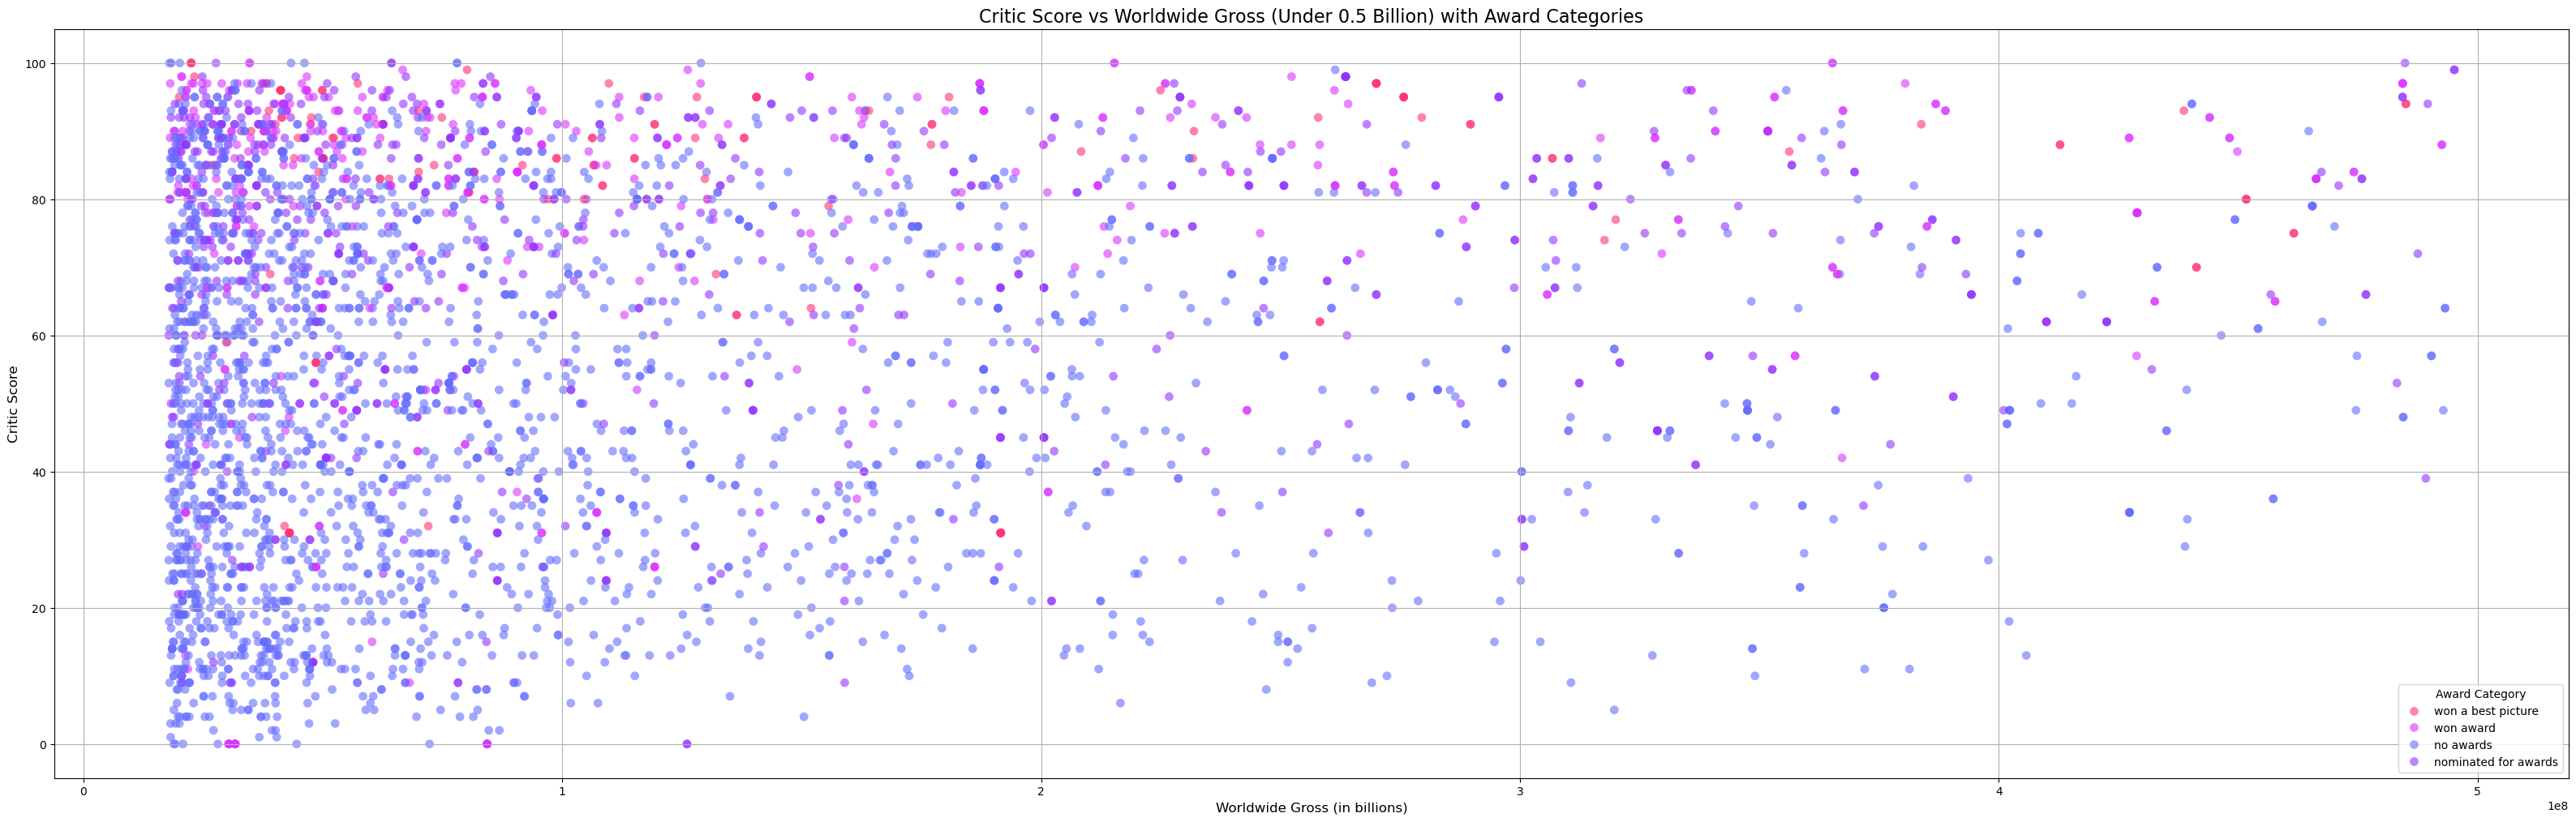

In [91]:
df = pd.read_csv('success_metrics.csv')
#same classification 
def classify_awards(row):
    best_picture_keywords=['best picture', 'best motion picture', 'outstanding motion picture', 'best film']
    has_best_picture=any(keyword.lower() in str(row['awards_won']).lower() for keyword in best_picture_keywords)
    has_nominations=pd.notna(row['awards_nominated']) and len(row['awards_nominated']) > 0
    has_wins=pd.notna(row['awards_won']) and len(row['awards_won']) > 0
    if not has_nominations and not has_wins:
        return 'no awards'
    elif has_nominations and not has_wins:
        return 'nominated for awards'
    elif has_wins:
        if has_best_picture:
            return 'won a best picture'
        else:
            return 'won award'
df['award_category']=df.apply(classify_awards, axis=1)
#removing if missing gross 
df_cleaned=df.dropna(subset=['worldwide_gross'])
#just using ones under 0.5 billion to see lower values more easily
df_filtered=df_cleaned[df_cleaned['worldwide_gross'] < 0.5e9]

# creating the scatter plot
plt.figure(figsize=(40, 12))

category_colors={'no awards': '#656CFE','nominated for awards': '#9333FF','won award': '#DA33FF', 'won a best picture': '#FF3377'}

#using same cusomisation 
sns.scatterplot(data=df_filtered, x='worldwide_gross', y='critic_score', hue='award_category', palette=category_colors, s=60, alpha=0.6, edgecolor='none')
plt.title('Critic Score vs Worldwide Gross (Under 0.5 Billion) with Award Categories', fontsize=16)
plt.xlabel('Worldwide Gross (in billions)', fontsize=12)
plt.ylabel('Critic Score', fontsize=12)
plt.legend(title='Award Category')
plt.grid(True)

# Show the plot
plt.show()


In [95]:
file_path = 'success_metrics.csv'
data = pd.read_csv(file_path)
#
if 'audience_score' in data.columns and 'critic_score' in data.columns:
    correlation = data['audience_score'].corr(data['critic_score'])
print(correlation)



0.6708584098256842


In [97]:
file_path = 'success_metrics.csv'
data = pd.read_csv(file_path)
#
if 'audience_score' in data.columns and 'worldwide_gross' in data.columns:
    correlation = data['audience_score'].corr(data['worldwide_gross'])
print(correlation)


0.2670364185262746


In [99]:
file_path = 'success_metrics.csv'
data = pd.read_csv(file_path)
#
if 'critic_score' in data.columns and 'worldwide_gross' in data.columns:
    correlation = data['critic_score'].corr(data['worldwide_gross'])
print(correlation)


0.22815220814247322


In [3]:
import pandas as pd
df = pd.read_csv("success_metrics.csv") 
if 'nomination_count' in df.columns and 'award_count' in df.columns:
    nominated = df[df['nomination_count'] > 0]
    percent_nominated = (len(nominated) / len(df)) * 100
    winners = df[df['award_count'] > 0]
    percent_won = (len(winners) / len(df)) * 100

    print(f"Percentage of movies nominated for an award: {percent_nominated:.2f}%")
    print(f"Percentage of movies that won an award: {percent_won:.2f}%")

else:
    print("Columns 'nominations' and/or 'wins' not found in the dataset.")


Percentage of movies nominated for an award: 24.65%
Percentage of movies that won an award: 9.95%
